# Pra-Pemrosesan Dataset DAiSEE



## 0. Konfigurasi Path

Sesuaikan seluruh path di bawah ini dengan lokasi dataset dan folder kerja saya.

In [8]:
import os
import shutil
import cv2
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from tqdm import tqdm

# ============================================================
# KONFIGURASI -- SESUAIKAN DENGAN LOKASI ANDA
# ============================================================

BASE_ROOT = r"F:\Dataset Ta"

LABEL_DIR       = os.path.join(BASE_ROOT, r"DATASET\DAISEE\Labels")
BASE_VIDEO_DIR  = os.path.join(BASE_ROOT, r"DATASET\DAISEE\DataSet")
MODEL_DIR       = os.path.join(BASE_ROOT, "Models")

RELABEL_DIR     = os.path.join(BASE_ROOT, "Output_Relabel")
OUTPUT_DIR      = os.path.join(BASE_ROOT, "Output_Faces_ViT")
OUTPUT_DIR_224  = os.path.join(BASE_ROOT, "Output_Faces_ViT_224")

TARGET_SIZE  = (224, 224)
DETECT_CONF  = 0.5
N_FRAMES     = 10   # jumlah frame yang diambil merata per video

os.makedirs(RELABEL_DIR, exist_ok=True)

print("Konfigurasi path selesai.")
print(f"BASE_ROOT       : {BASE_ROOT}")
print(f"LABEL_DIR       : {LABEL_DIR}")
print(f"BASE_VIDEO_DIR  : {BASE_VIDEO_DIR}")
print(f"MODEL_DIR       : {MODEL_DIR}")
print(f"OUTPUT_DIR      : {OUTPUT_DIR}")
print(f"OUTPUT_DIR_224  : {OUTPUT_DIR_224}")

Konfigurasi path selesai.
BASE_ROOT       : F:\Dataset Ta
LABEL_DIR       : F:\Dataset Ta\DATASET\DAISEE\Labels
BASE_VIDEO_DIR  : F:\Dataset Ta\DATASET\DAISEE\DataSet
MODEL_DIR       : F:\Dataset Ta\Models
OUTPUT_DIR      : F:\Dataset Ta\Output_Faces_ViT
OUTPUT_DIR_224  : F:\Dataset Ta\Output_Faces_ViT_224


## 1. Pelabelan Ulang (Relabel)

Mengikuti aturan kombinasi `Engagement` dan `Confusion` yang diadaptasi dari Malekshahi, dkk. (2024). Dilakukan **per split bawaan DAiSEE** (Train/Validation/Test terpisah), sehingga tidak ada pencampuran video antar split di tahap ini.

In [2]:
def get_relabel(row):
    """
    Aturan pelabelan ulang (kebijakan Engagement;Confusion, Malekshahi dkk. 2024):
      - Engagement == 0                                -> Disengaged (0)
      - Engagement == 1 dan Confusion in [0, 3]         -> Disengaged (0)
      - selain kondisi di atas                          -> Engaged (1)
    """
    engagement = row["Engagement"]
    confusion = row["Confusion"]

    if engagement == 0:
        return 0
    if engagement == 1 and confusion in [0, 3]:
        return 0
    return 1


relabel_summary = []

for split in ["Train", "Validation", "Test"]:
    src_csv = os.path.join(LABEL_DIR, f"{split}Labels.csv")

    if not os.path.isfile(src_csv):
        raise FileNotFoundError(f"CSV label tidak ditemukan: {src_csv}")

    df = pd.read_csv(src_csv)
    df.columns = [c.strip() for c in df.columns]

    df["NewLabel"] = df.apply(get_relabel, axis=1)

    out_csv = os.path.join(RELABEL_DIR, f"{split}_Relabel.csv")
    df.to_csv(out_csv, index=False)

    relabel_summary.append([
        split,
        int((df["NewLabel"] == 0).sum()),
        int((df["NewLabel"] == 1).sum()),
        len(df)
    ])

    print(f"[{split}] disimpan -> {out_csv} ({len(df)} baris)")

summary_df = pd.DataFrame(
    relabel_summary,
    columns=["Dataset", "Disengaged", "Engaged", "Total"]
)
summary_df.to_csv(os.path.join(RELABEL_DIR, "Distribusi_Setelah_Relabel.csv"), index=False)

print("\n=== Distribusi Setelah Pelabelan Ulang (untuk Tabel 4.2) ===")
print(summary_df.to_string(index=False))

[Train] disimpan -> F:\Dataset Ta\Output_Relabel\Train_Relabel.csv (5358 baris)
[Validation] disimpan -> F:\Dataset Ta\Output_Relabel\Validation_Relabel.csv (1429 baris)
[Test] disimpan -> F:\Dataset Ta\Output_Relabel\Test_Relabel.csv (1784 baris)

=== Distribusi Setelah Pelabelan Ulang (untuk Tabel 4.2) ===
   Dataset  Disengaged  Engaged  Total
     Train         148     5210   5358
Validation         104     1325   1429
      Test          52     1732   1784


In [27]:
import os
import pandas as pd

# ==========================================================
# PATH
# ==========================================================

LABEL_DIR = r"F:\Dataset Ta\DATASET\DAISEE\Labels"          # CSV asli DAiSEE
RELABEL_DIR = r"F:\Dataset Ta\Output_Relabel"                      # CSV hasil relabel

print("="*80)
print("AUDIT CSV RAW vs RELABEL")
print("="*80)

splits = ["Train", "Validation", "Test"]

total_raw = 0
total_relabel = 0

for split in splits:

    print(f"\n{'='*25} {split} {'='*25}")

    raw_csv = os.path.join(LABEL_DIR, f"{split}Labels.csv")
    relabel_csv = os.path.join(RELABEL_DIR, f"{split}_Relabel.csv")

    raw_df = pd.read_csv(raw_csv)
    relabel_df = pd.read_csv(relabel_csv)

    # Hilangkan spasi nama kolom
    raw_df.columns = raw_df.columns.str.strip()
    relabel_df.columns = relabel_df.columns.str.strip()

    # Normalisasi ClipID
    raw_clip = (
        raw_df["ClipID"]
        .astype(str)
        .str.lower()
        .str.replace(".avi", "", regex=False)
        .str.replace(".mp4", "", regex=False)
        .str.strip()
    )

    relabel_clip = (
        relabel_df["ClipID"]
        .astype(str)
        .str.lower()
        .str.replace(".avi", "", regex=False)
        .str.replace(".mp4", "", regex=False)
        .str.strip()
    )

    raw_set = set(raw_clip)
    relabel_set = set(relabel_clip)

    missing = sorted(raw_set - relabel_set)
    extra = sorted(relabel_set - raw_set)

    print(f"Raw CSV          : {len(raw_df)}")
    print(f"Relabel CSV      : {len(relabel_df)}")
    print(f"Unique Raw Clip  : {len(raw_set)}")
    print(f"Unique Relabel   : {len(relabel_set)}")

    print(f"Missing ClipID   : {len(missing)}")
    print(f"Extra ClipID     : {len(extra)}")

    if len(missing) > 0:
        print("\nContoh Missing (maks 10):")
        for c in missing[:10]:
            print("  ", c)

    if len(extra) > 0:
        print("\nContoh Extra (maks 10):")
        for c in extra[:10]:
            print("  ", c)

    if (
        len(raw_df) == len(relabel_df)
        and len(missing) == 0
        and len(extra) == 0
    ):
        print("✅ PASS")
    else:
        print("❌ TIDAK SAMA")

    total_raw += len(raw_df)
    total_relabel += len(relabel_df)

print("\n" + "="*80)
print("RINGKASAN")
print("="*80)
print(f"Total Raw CSV      : {total_raw}")
print(f"Total Relabel CSV  : {total_relabel}")

if total_raw == total_relabel:
    print("✅ Jumlah data tetap setelah relabel.")
else:
    print("❌ Jumlah data berubah setelah relabel.")

AUDIT CSV RAW vs RELABEL

========================= Train =========================
Raw CSV          : 5358
Relabel CSV      : 5358
Unique Raw Clip  : 5358
Unique Relabel   : 5358
Missing ClipID   : 0
Extra ClipID     : 0
✅ PASS

========================= Validation =========================
Raw CSV          : 1429
Relabel CSV      : 1429
Unique Raw Clip  : 1429
Unique Relabel   : 1429
Missing ClipID   : 0
Extra ClipID     : 0
✅ PASS

========================= Test =========================
Raw CSV          : 1784
Relabel CSV      : 1784
Unique Raw Clip  : 1784
Unique Relabel   : 1784
Missing ClipID   : 0
Extra ClipID     : 0
✅ PASS

RINGKASAN
Total Raw CSV      : 8571
Total Relabel CSV  : 8571
✅ Jumlah data tetap setelah relabel.


## 2. Indexing Video Mentah + Cek Duplikasi ClipID

Sebelum ekstraksi, seluruh video pada `BASE_VIDEO_DIR` diindeks berdasarkan nama *clip* (tanpa ekstensi). Dilakukan juga pengecekan apakah ada nama *clip* yang duplikat di lokasi fisik berbeda -- ini penting karena kalau ada duplikasi, video yang salah bisa tertukar saat proses pencocokan ke label.

In [3]:
print("Mengindeks seluruh video mentah...")

video_index = {}
duplicates = defaultdict(list)

for root, _, files in os.walk(BASE_VIDEO_DIR):
    for f in files:
        if not f.lower().endswith((".avi", ".mp4")):
            continue

        clip = os.path.splitext(f)[0].lower().strip()
        full_path = os.path.join(root, f)

        if clip in video_index:
            duplicates[clip].append(full_path)
        else:
            video_index[clip] = full_path

print(f"Total video unik terindeks : {len(video_index)}")

if duplicates:
    print(f"\nPERINGATAN: {len(duplicates)} ClipID duplikat ditemukan!")
    print("Video dengan ClipID sama di lokasi berbeda dapat menyebabkan salah pencocokan label.")
    for k, paths in list(duplicates.items())[:10]:
        print(f"  {k} -> {paths[:3]}")
    print("\n>>> Mohon periksa manual sebelum melanjutkan ke tahap ekstraksi. <<<")
else:
    print("Tidak ada ClipID duplikat. Aman untuk melanjutkan.")

Mengindeks seluruh video mentah...
Total video unik terindeks : 9067
Tidak ada ClipID duplikat. Aman untuk melanjutkan.


## 3. Ekstraksi *Frame* Wajah (per split bawaan DAiSEE)

**Perbaikan yang saya lakukan:**
- `OUTPUT_DIR` dihapus total (`shutil.rmtree`) sebelum ekstraksi dimulai, sehingga tidak ada sisa file dari pipeline lama (mis. hasil NearMiss-2 / re-split lama) yang tercampur dengan hasil baru.
- Setiap video hanya diproses berdasarkan CSV split-nya masing-masing (`Train_Relabel.csv`, `Validation_Relabel.csv`, `Test_Relabel.csv`), sehingga seluruh *frame* dari satu video otomatis selalu berada pada satu subset yang sama -- tidak ada kemungkinan tersebar ke subset lain.

In [4]:
# ============================================================
# PEMBERSIHAN FOLDER OUTPUT -- WAJIB sebelum ekstraksi
# ============================================================
if os.path.exists(OUTPUT_DIR):
    print(f"Menghapus folder lama: {OUTPUT_DIR}")
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Folder {OUTPUT_DIR} sudah bersih, siap menulis data baru.\n")

# ============================================================
# LOAD FACE DETECTOR (DNN SSD ResNet-10, via OpenCV)
# ============================================================
proto_path = os.path.join(MODEL_DIR, "deploy.prototxt")
model_path = os.path.join(MODEL_DIR, "res10_300x300_ssd_iter_140000.caffemodel")

if not (os.path.isfile(proto_path) and os.path.isfile(model_path)):
    raise FileNotFoundError("File model face detector tidak ditemukan di MODEL_DIR.")

net = cv2.dnn.readNetFromCaffe(proto_path, model_path)
print("Face detector berhasil dimuat.\n")


def norm_clipid(x):
    return str(x).lower().replace(".avi", "").replace(".mp4", "").strip()


extraction_summary = []

for split in ["Train", "Validation", "Test"]:
    print(f"\n========== {split} ==========")

    csv_path = os.path.join(RELABEL_DIR, f"{split}_Relabel.csv")
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    total_video = 0
    failed_video = 0
    saved_faces = 0
    missing_clips = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=split):

        clip_id = norm_clipid(row["ClipID"])
        label = int(row["NewLabel"])

        if clip_id == "" or clip_id not in video_index:
            failed_video += 1
            missing_clips.append(clip_id)
            continue

        video_path = video_index[clip_id]
        total_video += 1

        save_dir = os.path.join(OUTPUT_DIR, split.lower(), str(label))
        os.makedirs(save_dir, exist_ok=True)

        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)

        if total_frames <= 0:
            cap.release()
            failed_video += 1
            continue

        frame_positions = np.linspace(0, total_frames - 1, N_FRAMES, dtype=int)

        for idx, frame_no in enumerate(frame_positions):
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_no))
            ret, frame = cap.read()

            if not ret or frame is None:
                continue

            h, w = frame.shape[:2]
            blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104.0, 177.0, 123.0))
            net.setInput(blob)
            detections = net.forward()

            best_face = None
            best_conf = 0.0

            for i in range(detections.shape[2]):
                confidence = float(detections[0, 0, i, 2])

                if confidence > DETECT_CONF and confidence > best_conf:
                    box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
                    x1, y1, x2, y2 = box.astype(int)
                    x1, y1 = max(0, x1), max(0, y1)
                    x2, y2 = min(w, x2), min(h, y2)

                    if x2 - x1 <= 0 or y2 - y1 <= 0:
                        continue

                    face = frame[y1:y2, x1:x2]
                    if face.size == 0:
                        continue

                    best_face = face
                    best_conf = confidence

            if best_face is not None:
                filename = f"{clip_id}_frame{idx+1}.jpg"
                cv2.imwrite(os.path.join(save_dir, filename), best_face)
                saved_faces += 1

        cap.release()

    print(f"Video berhasil diproses : {total_video}")
    print(f"Video gagal/hilang      : {failed_video}")
    print(f"Total wajah tersimpan   : {saved_faces}")

    if missing_clips:
        print(f"Contoh ClipID hilang (maks 10): {list(set(missing_clips))[:10]}")

    extraction_summary.append([split, total_video, failed_video, saved_faces])

print("\n======================================")
print("Ekstraksi wajah selesai untuk seluruh split.")
print("======================================")

Menghapus folder lama: F:\Dataset Ta\Output_Faces_ViT
Folder F:\Dataset Ta\Output_Faces_ViT sudah bersih, siap menulis data baru.

Face detector berhasil dimuat.


========== Train ==========


Train: 100%|██████████| 5358/5358 [49:16<00:00,  1.81it/s]  


Video berhasil diproses : 5357
Video gagal/hilang      : 1
Total wajah tersimpan   : 53567
Contoh ClipID hilang (maks 10): ['2100552061']

========== Validation ==========


Validation: 100%|██████████| 1429/1429 [12:27<00:00,  1.91it/s]


Video berhasil diproses : 1429
Video gagal/hilang      : 0
Total wajah tersimpan   : 14286

========== Test ==========


Test: 100%|██████████| 1784/1784 [16:27<00:00,  1.81it/s]

Video berhasil diproses : 1784
Video gagal/hilang      : 0
Total wajah tersimpan   : 17833

Ekstraksi wajah selesai untuk seluruh split.


## 4. Resize Citra ke 224x224

In [5]:
if os.path.exists(OUTPUT_DIR_224):
    print(f"Menghapus folder lama: {OUTPUT_DIR_224}")
    shutil.rmtree(OUTPUT_DIR_224)

os.makedirs(OUTPUT_DIR_224, exist_ok=True)

print("Mulai proses resize...\n")

total_resized = 0

for root, dirs, files in os.walk(OUTPUT_DIR):
    relative = os.path.relpath(root, OUTPUT_DIR)
    save_dir = os.path.join(OUTPUT_DIR_224, relative)
    os.makedirs(save_dir, exist_ok=True)

    for file in files:
        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = os.path.join(root, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        resized = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
        cv2.imwrite(os.path.join(save_dir, file), resized)

        total_resized += 1
        if total_resized % 1000 == 0:
            print(f"{total_resized} citra selesai di-resize...")

print("\n===================================")
print("Resize selesai")
print(f"Total citra   : {total_resized}")
print(f"Ukuran akhir  : {TARGET_SIZE[0]} x {TARGET_SIZE[1]}")
print(f"Folder output : {OUTPUT_DIR_224}")
print("===================================")

Mulai proses resize...

1000 citra selesai di-resize...
2000 citra selesai di-resize...
3000 citra selesai di-resize...
4000 citra selesai di-resize...
5000 citra selesai di-resize...
6000 citra selesai di-resize...
7000 citra selesai di-resize...
8000 citra selesai di-resize...
9000 citra selesai di-resize...
10000 citra selesai di-resize...
11000 citra selesai di-resize...
12000 citra selesai di-resize...
13000 citra selesai di-resize...
14000 citra selesai di-resize...
15000 citra selesai di-resize...
16000 citra selesai di-resize...
17000 citra selesai di-resize...
18000 citra selesai di-resize...
19000 citra selesai di-resize...
20000 citra selesai di-resize...
21000 citra selesai di-resize...
22000 citra selesai di-resize...
23000 citra selesai di-resize...
24000 citra selesai di-resize...
25000 citra selesai di-resize...
26000 citra selesai di-resize...
27000 citra selesai di-resize...
28000 citra selesai di-resize...
29000 citra selesai di-resize...
30000 citra selesai di-resiz

## 5. Verifikasi Data Leakage 

**Perbaikan kunci:** `video_id` diambil dengan `.split("_frame")[0]`, sesuai format nama file yang sesungguhnya dibuat pada tahap ekstraksi (`{clip_id}_frame{N}.jpg`). Versi lama yang memakai `.split("_sec")[0]` tidak pernah cocok dengan pola nama file ini sehingga leakage tidak pernah bisa terdeteksi -- verifikasi berikut ini menggantikannya.

In [6]:
video_map = defaultdict(set)

for subset in ["train", "validation", "test"]:
    subset_path = os.path.join(OUTPUT_DIR_224, subset)

    if not os.path.isdir(subset_path):
        continue

    for label in os.listdir(subset_path):
        label_path = os.path.join(subset_path, label)

        if not os.path.isdir(label_path):
            continue

        for file in os.listdir(label_path):
            if not file.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            # PERBAIKAN: split berdasarkan "_frame", sesuai nama file asli
            video_id = file.split("_frame")[0].lower().strip()
            video_map[video_id].add(subset)

leakage = {vid: subs for vid, subs in video_map.items() if len(subs) > 1}

print("=" * 60)
print(f"Total video unik terverifikasi : {len(video_map)}")
print("=" * 60)

if not leakage:
    print("TIDAK ADA DATA LEAKAGE")
    print("Setiap video hanya muncul pada satu subset (train/validation/test).")
else:
    print("DATA LEAKAGE TERDETEKSI!")
    print(f"Jumlah video yang overlap antar subset: {len(leakage)}")
    print()
    for vid, subs in list(leakage.items())[:50]:
        print(f"  {vid} -> muncul di subset: {subs}")
    print("\n>>> JANGAN lanjut ke tahap training sebelum masalah ini diperbaiki! <<<")

Total video unik terverifikasi : 8570
TIDAK ADA DATA LEAKAGE
Setiap video hanya muncul pada satu subset (train/validation/test).


## 6. Ringkasan Statistik Akhir (untuk Tabel 4.4 dan Bab IV)

In [7]:
print("=== Jumlah citra per subset per kelas (untuk Tabel 4.4) ===\n")

final_stats = []

for subset in ["train", "validation", "test"]:
    for label in ["0", "1"]:
        path = os.path.join(OUTPUT_DIR_224, subset, label)

        if not os.path.isdir(path):
            count = 0
        else:
            count = len([f for f in os.listdir(path) if f.lower().endswith((".jpg", ".jpeg", ".png"))])

        final_stats.append([subset, "Disengaged" if label == "0" else "Engaged", count])
        print(f"{subset:12s} | {'Disengaged' if label=='0' else 'Engaged':10s} | {count}")

final_stats_df = pd.DataFrame(final_stats, columns=["Subset", "Kelas", "Jumlah_Citra"])
final_stats_df.to_csv(os.path.join(BASE_ROOT, "Distribusi_Final_Tabel44.csv"), index=False)

total_all = final_stats_df["Jumlah_Citra"].sum()
print(f"\nTotal keseluruhan citra: {total_all}")
print(f"\nDisimpan ke: {os.path.join(BASE_ROOT, 'Distribusi_Final_Tabel44.csv')}")

=== Jumlah citra per subset per kelas (untuk Tabel 4.4) ===

train        | Disengaged | 1480
train        | Engaged    | 52087
validation   | Disengaged | 1037
validation   | Engaged    | 13249
test         | Disengaged | 520
test         | Engaged    | 17313

Total keseluruhan citra: 85686

Disimpan ke: F:\Dataset Ta\Distribusi_Final_Tabel44.csv


In [8]:
print("=== Distribusi ukuran citra sebelum resize (opsional, untuk Tabel 4.5) ===\n")

size_counter = Counter()
widths, heights = [], []
total_images = failed_images = 0

for root, _, files in os.walk(OUTPUT_DIR):
    for file in files:
        if not file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img = cv2.imread(os.path.join(root, file))
        if img is None:
            failed_images += 1
            continue

        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)
        size_counter[(w, h)] += 1
        total_images += 1

print(f"Total citra    : {total_images}")
print(f"Gagal dibaca   : {failed_images}")
print(f"Ukuran unik    : {len(size_counter)}")
print(f"Lebar min/maks : {min(widths)} / {max(widths)}")
print(f"Tinggi min/maks: {min(heights)} / {max(heights)}")
print("\nUkuran paling sering muncul:")
for (w, h), count in size_counter.most_common(20):
    print(f"  {w} x {h} : {count}")

=== Distribusi ukuran citra sebelum resize (opsional, untuk Tabel 4.5) ===

Total citra    : 85686
Gagal dibaca   : 0
Ukuran unik    : 7971
Lebar min/maks : 40 / 354
Tinggi min/maks: 57 / 426

Ukuran paling sering muncul:
  118 x 158 : 158
  117 x 158 : 155
  117 x 157 : 149
  119 x 156 : 124
  132 x 176 : 123
  117 x 159 : 121
  119 x 159 : 119
  109 x 146 : 119
  119 x 157 : 117
  118 x 157 : 116
  117 x 156 : 116
  118 x 156 : 116
  130 x 177 : 115
  119 x 158 : 114
  116 x 158 : 114
  109 x 141 : 112
  118 x 159 : 110
  119 x 161 : 103
  117 x 154 : 103
  109 x 143 : 103


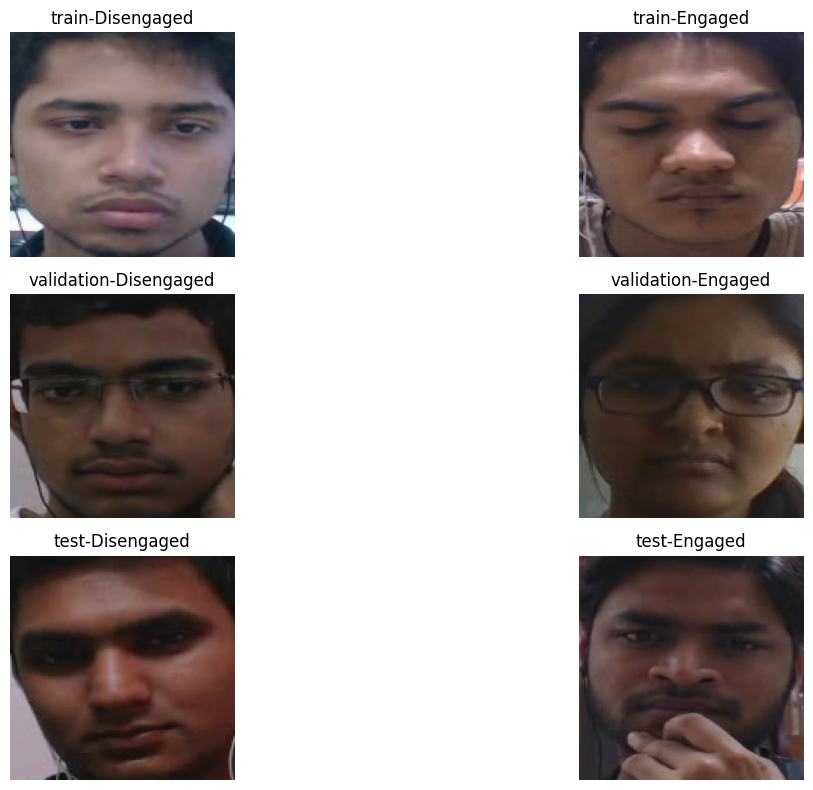

In [10]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(15, 8))
i = 1

for subset in ["train", "validation", "test"]:
    for label in ["0", "1"]:
        folder = os.path.join(OUTPUT_DIR_224, subset, label)

        if not os.path.isdir(folder) or len(os.listdir(folder)) == 0:
            continue

        file = random.choice(os.listdir(folder))
        img = cv2.imread(os.path.join(folder, file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(3, 2, i)
        plt.imshow(img)
        plt.title(f"{subset}-{'Disengaged' if label=='0' else 'Engaged'}")
        plt.axis("off")
        i += 1

plt.tight_layout()
plt.show()

# cek apakah bocor atau tidak

In [12]:
VAL_LABEL = os.path.join(RELABEL_DIR, "Validation_Relabel.csv")
TRAIN_LABEL = os.path.join(RELABEL_DIR, "Train_Relabel.csv")   
TEST_LABEL = os.path.join(RELABEL_DIR, "Test_Relabel.csv")

In [13]:
from itertools import combinations

print("="*60)
print("CEK OVERLAP CLIPID ANTAR SPLIT")
print("="*60)

train_df = pd.read_csv(TRAIN_LABEL)
val_df   = pd.read_csv(VAL_LABEL)
test_df  = pd.read_csv(TEST_LABEL)

train_ids = set(train_df["ClipID"].astype(str))
val_ids   = set(val_df["ClipID"].astype(str))
test_ids  = set(test_df["ClipID"].astype(str))

split_dict = {
    "Train": train_ids,
    "Validation": val_ids,
    "Test": test_ids
}

found = False

for a, b in combinations(split_dict.keys(), 2):

    overlap = split_dict[a] & split_dict[b]

    print(f"{a} vs {b}")

    if len(overlap) == 0:
        print("   ✓ Tidak ada ClipID yang sama")
    else:
        found = True
        print(f"   ❌ Ada {len(overlap)} ClipID overlap")
        print(list(sorted(overlap))[:20])

print()

if not found:
    print("✅ Tidak ditemukan data leakage pada level ClipID.")
else:
    print("❌ Split bermasalah. Jangan lanjut ekstraksi.")

CEK OVERLAP CLIPID ANTAR SPLIT
Train vs Validation
   ✓ Tidak ada ClipID yang sama
Train vs Test
   ✓ Tidak ada ClipID yang sama
Validation vs Test
   ✓ Tidak ada ClipID yang sama

✅ Tidak ditemukan data leakage pada level ClipID.


In [14]:
from collections import defaultdict

print("="*60)
print("CEK SUBJECT LEAKAGE")
print("="*60)

subject_split = defaultdict(set)

for root, dirs, files in os.walk(BASE_VIDEO_DIR):

    for file in files:

        if file.endswith(".avi"):

            clip = os.path.splitext(file)[0]

            if clip in train_ids:
                split = "Train"
            elif clip in val_ids:
                split = "Validation"
            elif clip in test_ids:
                split = "Test"
            else:
                continue

            rel = os.path.relpath(root, BASE_VIDEO_DIR)
            subject = rel.split(os.sep)[0]

            subject_split[subject].add(split)

problem = False

for subject, splits in subject_split.items():

    if len(splits) > 1:

        problem = True

        print(
            f"❌ Subject {subject} muncul di {sorted(list(splits))}"
        )

if not problem:
    print("✅ Tidak ditemukan subject leakage.")

CEK SUBJECT LEAKAGE
✅ Tidak ditemukan subject leakage.


In [3]:
from pathlib import Path

# ===============================
# DATASET VIDEO RAW
# ===============================

BASE_VIDEO_DIR = Path(r"F:\Dataset Ta\DATASET\DAISEE\DataSet")

# ===============================
# CSV ASLI DAISEE
# ===============================

ORIGINAL_LABEL_DIR = Path(r"F:\Dataset Ta\DATASET\DAISEE\Labels")

TRAIN_ORIGINAL = ORIGINAL_LABEL_DIR / "TrainLabels.csv"
VAL_ORIGINAL   = ORIGINAL_LABEL_DIR / "ValidationLabels.csv"
TEST_ORIGINAL  = ORIGINAL_LABEL_DIR / "TestLabels.csv"

# ===============================
# CSV HASIL RELABEL
# ===============================

RELABEL_DIR = Path(r"F:\Dataset Ta\Output_Relabel")

TRAIN_RELABEL = RELABEL_DIR / "Train_Relabel.csv"
VAL_RELABEL   = RELABEL_DIR / "Validation_Relabel.csv"
TEST_RELABEL  = RELABEL_DIR / "Test_Relabel.csv"

# ===============================
# HASIL EKSTRAKSI FRAME
# ===============================

OUTPUT_DIR = Path(r"F:\Dataset Ta\Output_Faces_ViT_224")

TRAIN_FRAME = OUTPUT_DIR / "train"
VAL_FRAME   = OUTPUT_DIR / "validation"
TEST_FRAME  = OUTPUT_DIR / "test"

In [4]:
import pandas as pd

print("="*60)
print("CEK RELABEL TIDAK MENGUBAH SPLIT")
print("="*60)

splits = [
    ("Train", TRAIN_ORIGINAL, TRAIN_RELABEL),
    ("Validation", VAL_ORIGINAL, VAL_RELABEL),
    ("Test", TEST_ORIGINAL, TEST_RELABEL),
]

for name, ori, rel in splits:

    ori_df = pd.read_csv(ori)
    rel_df = pd.read_csv(rel)

    ori_clip = set(ori_df["ClipID"].astype(str))
    rel_clip = set(rel_df["ClipID"].astype(str))

    print(f"\n{name}")

    print("Jumlah Clip Original :", len(ori_clip))
    print("Jumlah Clip Relabel  :", len(rel_clip))

    if ori_clip == rel_clip:
        print("✅ ClipID IDENTIK")
    else:

        print("❌ Ada ClipID yang berubah")

        print("Hanya Original:")
        print(sorted(list(ori_clip-rel_clip))[:10])

        print("Hanya Relabel:")
        print(sorted(list(rel_clip-ori_clip))[:10])

CEK RELABEL TIDAK MENGUBAH SPLIT

Train
Jumlah Clip Original : 5358
Jumlah Clip Relabel  : 5358
✅ ClipID IDENTIK

Validation
Jumlah Clip Original : 1429
Jumlah Clip Relabel  : 1429
✅ ClipID IDENTIK

Test
Jumlah Clip Original : 1784
Jumlah Clip Relabel  : 1784
✅ ClipID IDENTIK


In [21]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

# =====================================================
# PATH
# =====================================================

BASE_VIDEO_DIR = r"F:\Dataset Ta\DATASET\DAISEE\DataSet"
OUTPUT_DIR     = r"F:\Dataset Ta\Output_Faces_ViT_224"
MODEL_DIR      = r"F:\Dataset Ta\Models"

DEBUG_DIR = r"F:\Dataset Ta\Debug_Frame_Gagal"
os.makedirs(DEBUG_DIR, exist_ok=True)

N_FRAMES = 10
DETECT_CONF = 0.5

# =====================================================
# LOAD MODEL
# =====================================================

proto_path = os.path.join(MODEL_DIR,"deploy.prototxt")
model_path = os.path.join(MODEL_DIR,"res10_300x300_ssd_iter_140000.caffemodel")

net = cv2.dnn.readNetFromCaffe(proto_path,model_path)

# =====================================================
# BUILD VIDEO INDEX
# =====================================================

video_index = {}

for video in Path(BASE_VIDEO_DIR).rglob("*.avi"):

    clip = video.stem.lower().strip()

    video_index[clip] = str(video)

print(f"Total video : {len(video_index)}")

# =====================================================
# HITUNG FRAME PER CLIP
# =====================================================

clip_counter = defaultdict(int)
clip_split = {}

for split in ["train","validation","test"]:

    split_dir = os.path.join(OUTPUT_DIR,split)

    for root,dirs,files in os.walk(split_dir):

        for f in files:

            if f.endswith(".jpg"):

                clip = f.split("_frame")[0].lower()

                clip_counter[clip]+=1

                clip_split[clip]=split

# =====================================================
# CARI CLIP <10 FRAME
# =====================================================

problem_clip = []

for clip,nframe in clip_counter.items():

    if nframe<10:

        problem_clip.append((clip,clip_split[clip],nframe))

print("="*60)
print(f"Video bermasalah : {len(problem_clip)}")
print("="*60)

report=[]

# =====================================================
# DEBUG SATU PERSATU
# =====================================================

for clip,split,nframe in problem_clip:

    print(f"\n{clip} ({nframe} frame)")

    if clip not in video_index:

        print("Video tidak ditemukan")
        continue

    video_path = video_index[clip]

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_positions=np.linspace(
        0,
        total_frames-1,
        N_FRAMES,
        dtype=int
    )

    save_dir=os.path.join(
        DEBUG_DIR,
        split,
        clip
    )

    os.makedirs(save_dir,exist_ok=True)

    for idx,frame_no in enumerate(frame_positions):

        cap.set(cv2.CAP_PROP_POS_FRAMES,int(frame_no))

        ret,frame=cap.read()

        if not ret:

            report.append([
                split,
                clip,
                idx+1,
                frame_no,
                "READ_FAIL"
            ])

            continue

        h,w=frame.shape[:2]

        blob=cv2.dnn.blobFromImage(
            frame,
            1.0,
            (300,300),
            (104,177,123)
        )

        net.setInput(blob)

        detections=net.forward()

        found=False

        best_conf=0

        for i in range(detections.shape[2]):

            conf=float(detections[0,0,i,2])

            if conf>DETECT_CONF:

                found=True
                best_conf=max(best_conf,conf)

        if not found:

            cv2.imwrite(
                os.path.join(
                    save_dir,
                    f"frame_{idx+1}.jpg"
                ),
                frame
            )

            report.append([
                split,
                clip,
                idx+1,
                frame_no,
                "NO_FACE"
            ])

        else:

            report.append([
                split,
                clip,
                idx+1,
                frame_no,
                f"FACE ({best_conf:.3f})"
            ])

    cap.release()

# =====================================================
# SAVE CSV
# =====================================================

df=pd.DataFrame(
    report,
    columns=[
        "Split",
        "ClipID",
        "Frame_Target",
        "Video_Frame",
        "Status"
    ]
)

csv_path=os.path.join(DEBUG_DIR,"debug_report.csv")

df.to_csv(csv_path,index=False)

print("\nSelesai")
print(csv_path)

Total video : 8231
Video bermasalah : 10

2100522019 (8 frame)

33702101290 (9 frame)
Video tidak ditemukan

5674960283 (7 frame)

5564630160 (9 frame)

8264120120 (9 frame)

8264120126 (9 frame)

8264120127 (9 frame)

8264120266 (8 frame)

9289010151 (9 frame)

9289010273 (9 frame)

Selesai
F:\Dataset Ta\Debug_Frame_Gagal\debug_report.csv


In [23]:
from pathlib import Path
from collections import defaultdict
import pandas as pd
import os

print("="*80)
print("AUDIT PREPROCESSING DAISEE")
print("="*80)

# =====================================================
# 1. RAW VIDEO
# =====================================================

raw_video = {}

for split in ["Train","Validation","Test"]:

    folder = Path(BASE_VIDEO_DIR)/split

    raw_video[split] = len(list(folder.rglob("*.avi")))

# =====================================================
# 2. RELABEL CSV
# =====================================================

csv_video = {}

csv_files = {
    "Train": os.path.join(RELABEL_DIR,"Train_Relabel.csv"),
    "Validation": os.path.join(RELABEL_DIR,"Validation_Relabel.csv"),
    "Test": os.path.join(RELABEL_DIR,"Test_Relabel.csv")
}

for split,file in csv_files.items():

    df = pd.read_csv(file)

    csv_video[split] = len(df)

# =====================================================
# 3. HASIL EKSTRAKSI
# =====================================================

processed_clip = defaultdict(set)
processed_frame = defaultdict(int)

folders = {
    "Train": TRAIN_FRAME,
    "Validation": VAL_FRAME,
    "Test": TEST_FRAME
}

frame_distribution = defaultdict(dict)

less10 = defaultdict(list)

for split,folder in folders.items():

    clip_frame = defaultdict(int)

    for root,dirs,files in os.walk(folder):

        for f in files:

            if not f.endswith(".jpg"):
                continue

            clip = f.split("_frame")[0]

            clip_frame[clip]+=1

    processed_clip[split] = set(clip_frame.keys())

    processed_frame[split] = sum(clip_frame.values())

    for clip,n in clip_frame.items():

        if n<10:

            less10[split].append((clip,n))

# =====================================================
# 4. VIDEO HILANG
# =====================================================

video_index={}

for video in Path(BASE_VIDEO_DIR).rglob("*.avi"):

    video_index[video.stem.lower()] = str(video)

missing_video = defaultdict(list)

for split,file in csv_files.items():

    df=pd.read_csv(file)

    for clip in df["ClipID"]:

        clip=str(clip).lower().replace(".avi","").strip()

        if clip not in video_index:

            missing_video[split].append(clip)

# =====================================================
# RINGKASAN
# =====================================================

print("\nRAW DATASET")
print("-"*60)

for split in raw_video:

    print(f"{split:<12}: {raw_video[split]}")

print(f"{'TOTAL':<12}: {sum(raw_video.values())}")

print("\nCSV RELABEL")
print("-"*60)

for split in csv_video:

    print(f"{split:<12}: {csv_video[split]}")

print(f"{'TOTAL':<12}: {sum(csv_video.values())}")

print("\nHASIL EKSTRAKSI")
print("-"*60)

for split in folders:

    print(f"{split:<12}: {len(processed_clip[split])} video | {processed_frame[split]} frame")

print(f"{'TOTAL':<12}: {sum(len(processed_clip[s]) for s in folders)} video | {sum(processed_frame.values())} frame")

print("\nVIDEO TIDAK DITEMUKAN")
print("-"*60)

for split in folders:

    print(f"{split:<12}: {len(missing_video[split])}")

print(f"{'TOTAL':<12}: {sum(len(missing_video[s]) for s in folders)}")

print("\nVIDEO DENGAN FRAME <10")
print("-"*60)

for split in folders:

    print(f"{split:<12}: {len(less10[split])}")

print(f"{'TOTAL':<12}: {sum(len(less10[s]) for s in folders)}")

# =====================================================
# DETAIL
# =====================================================

print("\n"+"="*80)
print("DETAIL VIDEO FRAME <10")
print("="*80)

for split in folders:

    print(f"\n{split}")

    if len(less10[split])==0:

        print("Tidak ada")

    else:

        for clip,n in less10[split]:

            print(f"{clip} -> {n} frame")

print("\n"+"="*80)
print("DETAIL VIDEO TIDAK DITEMUKAN")
print("="*80)

for split in folders:

    print(f"\n{split}")

    if len(missing_video[split])==0:

        print("Tidak ada")

    else:

        for clip in missing_video[split]:

            print(clip)

AUDIT PREPROCESSING DAISEE

RAW DATASET
------------------------------------------------------------
Train       : 4975
Validation  : 1536
Test        : 1720
TOTAL       : 8231

CSV RELABEL
------------------------------------------------------------
Train       : 5358
Validation  : 1429
Test        : 1784
TOTAL       : 8571

HASIL EKSTRAKSI
------------------------------------------------------------
Train       : 5357 video | 53567 frame
Validation  : 1429 video | 14286 frame
Test        : 1784 video | 17833 frame
TOTAL       : 8570 video | 85686 frame

VIDEO TIDAK DITEMUKAN
------------------------------------------------------------
Train       : 507
Validation  : 0
Test        : 146
TOTAL       : 653

VIDEO DENGAN FRAME <10
------------------------------------------------------------
Train       : 2
Validation  : 2
Test        : 6
TOTAL       : 10

DETAIL VIDEO FRAME <10

Train
2100522019 -> 8 frame
33702101290 -> 9 frame

Validation
5674960283 -> 7 frame
5564630160 -> 9 frame

Te

In [24]:
path_to_check = r"F:\Dataset Ta\cadangan\cadangan major\Output_Faces_ViT_224"
total_images = 0

for root_dir, _, files in os.walk(path_to_check):
    total_images += len([f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))])

print(f"Total citra di {path_to_check}: {total_images}")

Total citra di F:\Dataset Ta\cadangan\cadangan major\Output_Faces_ViT_224: 85686
